In [1]:
!pip install seaborn matplotlib scanpy numpy igraph harmonypy anndata celltypist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 

In [2]:
# -- Load libraries
import os
import scanpy as sc
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import harmonypy
import celltypist as ct
from celltypist import models

/usr/local/lib/python3.12/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [4]:
# -- Color Palettes
patient_colors_list = [
    sns.husl_palette(n_colors=1, h=h, s=0.9, l=0.65).as_hex()[0]
    for h in np.linspace(0.01, 0.70, 14)
]

# map to patient IDs
patient_ids = ["C01", "C02", "C03",
               "E01", "E02", "E03", "E04", "E05",
               "E06", "E07", "E08", "E09", "E10", "E11"]

patient_palette = dict(zip(patient_ids, patient_colors_list))

tissue_palette = {
    "Ctrl": "#7FA25C",
    "EuE":  "#028090",
    "EcP":  "#456990",
    "EcO":  "#CE7DA5"
}

immune_palette = {
    # -- Macrophages / Monocytes (warm tones)
    "Classical Monocytes": "#E07B54",
    "Non-Classical Monocytes":"#F2A65A",
    "Tissue Resident Macrophages": "#C14F3A",

    # -- Dendritic cells (purples)
    "cDC1": "#7B4FA6",
    "cDC2": "#A87DC2",
    "pDC": "#C9A8E0",

    # -- NK cells (greens)
    "CD16+ NK cells": "#2D8C6E",
    "CD16- NK cells": "#6DBF9E",
    "Cytotoxic NK T cells": "#A8D8B0",

    # -- T cells (blues)
    "CD4 T cells": "#2E6FA3",
    "CD8 T cells": "#5B9EC9",
    "Tregs": "#A8CBE0",

    # -- B cells (yellow)
    "B cells": "#E8C84A",

    # -- Proliferating (grey)
    "Proliferating": "#8C8C8C"
}

In [5]:
# -- Paths
input_path = "/content/drive/MyDrive/endo-immune-atlas/data/processed/GSE179640_total_clustering.h5ad"
output_path_data = "/content/drive/MyDrive/endo-immune-atlas/data/processed"
output_path_figures = "/content/drive/MyDrive/endo-immune-atlas/results/preprocessing"

os.makedirs(output_path_figures, exist_ok=True)

In [6]:
# -- Import object
combined = sc.read_h5ad(input_path)
combined

AnnData object with n_obs × n_vars = 94891 × 2000
    obs: 'sample_id', 'patient_id', 'tissue_type', 'condition', 'lesion_site', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'outlier_mt', 'doublet_score', 'predicted_doublet', 'leiden_res_0.01', 'leiden_res_0.02', 'leiden_res_0.05', 'cluster_label'
    var: 'hemos', 'ribos', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'cluster_label_colors', 'hvg', 'leiden_res_0.01', 'leiden_res_0.01_colors', 'leiden_res_0.02', 'leiden_res_0.02_colors', 'leiden_res_0.05', 'leiden_res_0.05_colors', 'log1p', 'neighbors', 'patient_id_colors', 'pca', 'predicted_doublet_colors', 'rank_genes_groups', 'scrublet', 'tissue_type_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectiv

In [7]:
# -- Subset immune cells (lymp & myeloid)
immune_obj = combined[combined.obs['cluster_label'].isin(['Lymphoid', 'Myeloid'])].copy()

In [8]:
# -- Normalize counts
sc.pp.normalize_total(immune_obj)

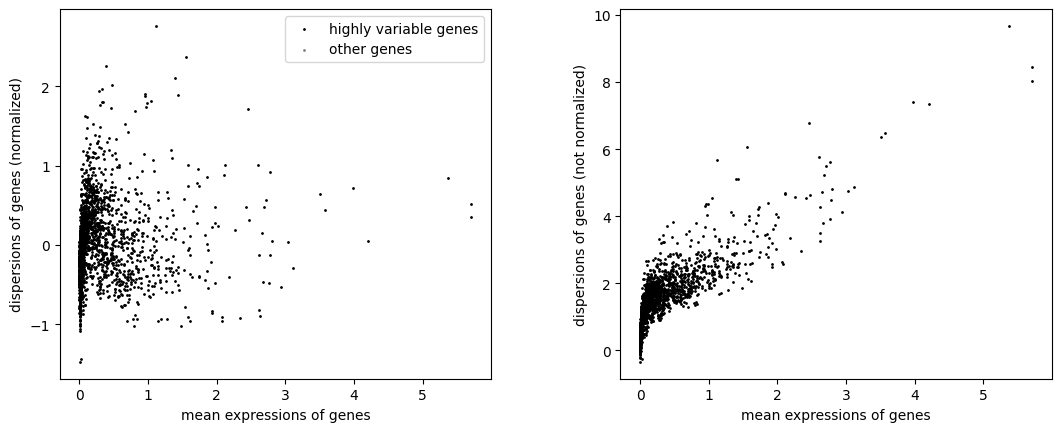

In [9]:
# -- Select HVGs
sc.pp.highly_variable_genes(immune_obj, n_top_genes=2000, batch_key="sample_id")

sc.pl.highly_variable_genes(immune_obj)


immune_obj = immune_obj[:, immune_obj.var["highly_variable"]].copy()

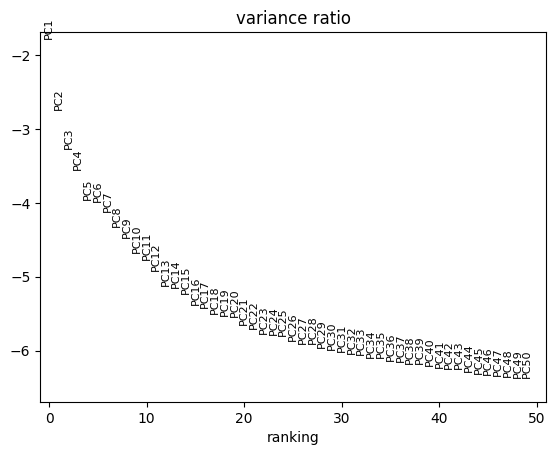

In [10]:
# -- Dimensionality Reduction
sc.tl.pca(immune_obj)
sc.pl.pca_variance_ratio(immune_obj,
                         n_pcs=50,
                         log=True)

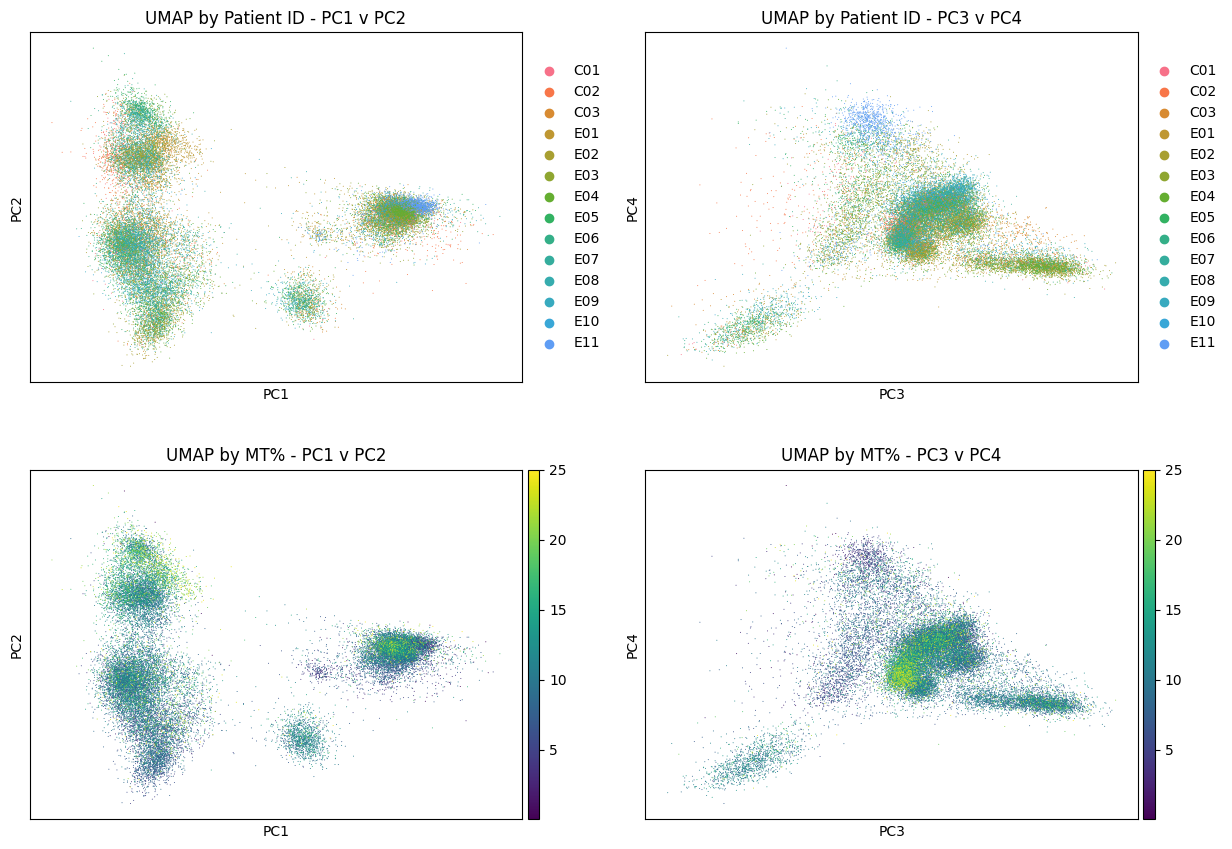

In [11]:
sc.pl.pca(
    immune_obj,
    color=["patient_id", "patient_id", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
    title = ["UMAP by Patient ID - PC1 v PC2", "UMAP by Patient ID - PC3 v PC4", "UMAP by MT% - PC1 v PC2","UMAP by MT% - PC3 v PC4"]
)

In [12]:
# -- Batch correction

ho = harmonypy.run_harmony(
    immune_obj.obsm["X_pca"],
    immune_obj.obs,
    "sample_id"
)

immune_obj.obsm["X_pca_harmony"] = ho.Z_corr

2026-06-14 23:21:17,770 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-06-14 23:21:17,772 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-06-14 23:21:17,774 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-06-14 23:21:17,776 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-06-14 23:21:17,779 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-06-14 23:21:17,779 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-06-14 23:21:17,780 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-06-14 23:21:17,781 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-06-14 23:21:17,782 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-06-14 23:21:17,783 - harmonypy - INFO -     theta: [2. 2. 2

In [13]:
# -- Nearest Neighbors
sc.pp.neighbors(
    immune_obj,
    use_rep="X_pca_harmony",
    n_neighbors=15
)

In [14]:
# -- UMAP
sc.tl.umap(immune_obj)

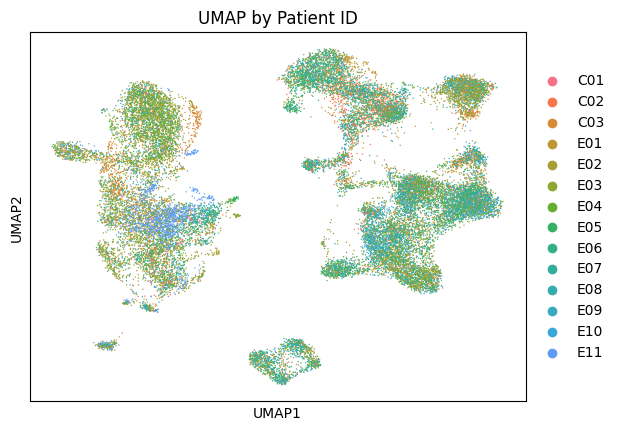

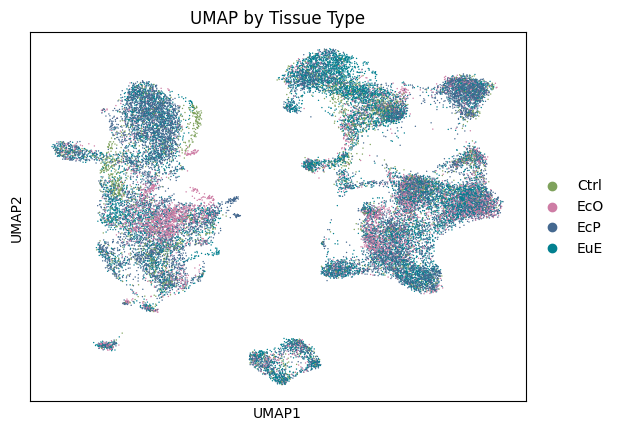

In [15]:
sc.pl.umap(
    immune_obj,
    color="patient_id",
    palette=patient_palette,
    size = 4,
    title = "UMAP by Patient ID"
)

sc.pl.umap(
    immune_obj,
    color="tissue_type",
    palette=tissue_palette,
    size = 4,
    title = "UMAP by Tissue Type"
)


In [16]:
# -- Cluster

for res in [0.2, 0.5, 1]:
    sc.tl.leiden(immune_obj,
                 key_added=f"leiden_res_{res:4.2f}",
                 resolution=res,
                 flavor="igraph"
                 )

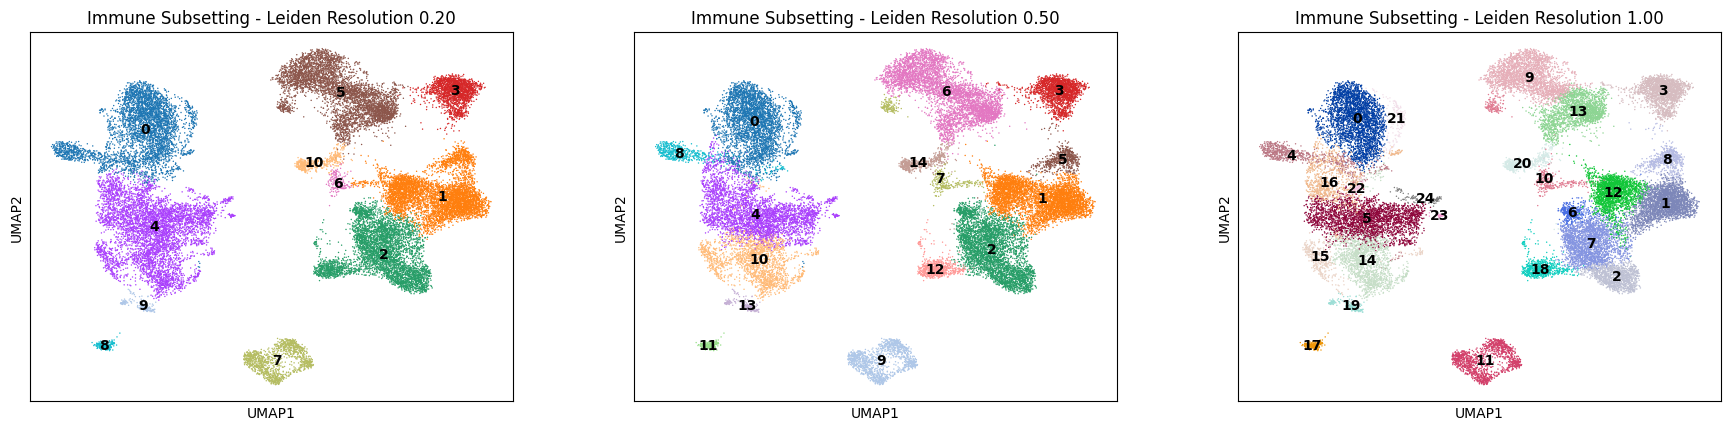

In [17]:
sc.pl.umap(
    immune_obj,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_1.00"],
    legend_loc="on data", title = ["Immune Subsetting - Leiden Resolution 0.20", "Immune Subsetting - Leiden Resolution 0.50", "Immune Subsetting - Leiden Resolution 1.00"]
)

plt.savefig(
    os.path.join(output_path_figures, "05_immune_leiden_res.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()


In [18]:
# -- Genes
sc.tl.rank_genes_groups(
    immune_obj,
    groupby="leiden_res_0.50",
    method="wilcoxon"
)

In [19]:
# -- Markers
markers = sc.get.rank_genes_groups_df(
    immune_obj,
    group=None
)

markers = markers[
    (markers["logfoldchanges"] > 1.5) &
    (markers["pvals_adj"] < 0.05)
]

for c in markers["group"].unique():
    print(f"\nCluster {c}")
    print(
        markers[markers["group"] == c]
        .sort_values("logfoldchanges", ascending=False)
        .head(10)["names"]
        .tolist()
    )


Cluster 0
['FOLR3', 'S100A12', 'S100A8', 'S100A9', 'FCN1', 'VCAN', 'NFE2', 'LYZ', 'CLEC4D', 'VNN3']

Cluster 1
['CD8B', 'CD8A', 'GZMK', 'CCL5', 'RCAN2', 'TNIP3', 'CD3D', 'LAG3', 'ZNF80', 'TRGV4']

Cluster 2
['IL7R', 'MAL', 'CD40LG', 'LRRN3', 'ADTRP', 'CCR7', 'TRABD2A', 'B3GALT2', 'LTB', 'LEF1']

Cluster 3
['FGFBP2', 'HBA1', 'KLRF1', 'MYOM2', 'AKR1C3', 'SPON2', 'MLC1', 'S1PR5', 'GNLY', 'CXCR1']

Cluster 4
['CCL18', 'HS3ST2', 'CCL13', 'CCL7', 'LILRB5', 'LYVE1', 'GPNMB', 'RNASE1', 'CD209', 'FOLR2']

Cluster 5
['GZMH', 'FGFBP2', 'NKG7', 'ADGRG1', 'TTC16', 'S1PR5', 'PROK2', 'KLRG1', 'CCL5', 'B3GAT1']

Cluster 6
['COX6A2', 'KRT81', 'ITGAD', 'ADGRG3', 'GNLY', 'KLRC1', 'KRT86', 'NCAM1', 'CYP26A1', 'TRDC']

Cluster 7
['ASPM', 'MKI67', 'TOP2A', 'RRM2', 'UBE2C', 'DLGAP5', 'GTSE1', 'TYMS', 'AURKB', 'CENPF']

Cluster 8
['LYPD2', 'CDKN1C', 'PTGDR2', 'HES4', 'AC100803.3', 'SMIM25', 'HCAR3', 'FCGR3A', 'LST1', 'FCN1']

Cluster 9
['VPREB3', 'LINC01781', 'PAX5', 'COL19A1', 'CD79A', 'FCRL1', 'IGHM', 'MS4

In [20]:
ct.models.download_models(model=["Immune_All_Low.pkl"], force_update=True)

model = ct.models.Model.load(model="Immune_All_Low.pkl")
predictions = ct.annotate(immune_obj, model="Immune_All_Low.pkl", majority_voting=True, over_clustering = "leiden_res_0.50")
# convert back to anndata||
immune_obj = predictions.to_adata()

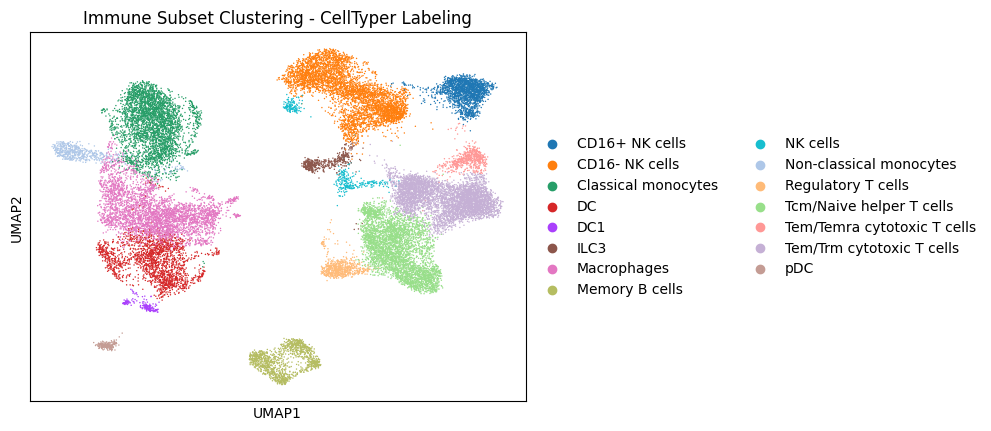

In [21]:
sc.pl.umap(immune_obj,
           color="majority_voting",
           ncols=1,
           title = "Immune Subset Clustering - CellTyper Labeling")

In [22]:
immune_obj.obs["leiden_res_0.50"].value_counts()

# -- Dropping cluster 14 due to ambiguity in gene markers and low cell count
# -- drop cluster 14
immune_obj = immune_obj[
    immune_obj.obs["leiden_res_0.50"] != "14"
].copy()

print(f"Cells remaining after dropping cluster 14: {immune_obj.n_obs}")

Cells remaining after dropping cluster 14: 27903


In [23]:
# -- Immune markers
immune_labels = {
    "0":  "Classical Monocytes",
    "1":  "CD8 T cells",
    "2":  "CD4 T cells",
    "3":  "CD16+ NK cells",
    "4":  "Tissue Resident Macrophages",
    "5":  "Cytotoxic NK T cells",
    "6":  "CD16- NK cells",
    "7":  "Proliferating",
    "8":  "Non-Classical Monocytes",
    "9":  "B cells",
    "10": "cDC2",
    "11": "pDC",
    "12": "Tregs",
    "13": "cDC1"
}

immune_obj.obs["immune_cell_type"] = immune_obj.obs["leiden_res_0.50"].map(immune_labels)

# verify no NaN values
print(immune_obj.obs["immune_cell_type"].value_counts())
print(immune_obj.obs["immune_cell_type"].isna().sum())

immune_cell_type
CD8 T cells                    4636
CD16- NK cells                 4412
CD4 T cells                    4134
Tissue Resident Macrophages    3608
Classical Monocytes            3444
cDC2                           1945
CD16+ NK cells                 1811
B cells                        1307
Tregs                           652
Cytotoxic NK T cells            606
Non-Classical Monocytes         560
Proliferating                   397
pDC                             207
cDC1                            184
Name: count, dtype: int64
0


In [24]:
# -- Final Clustering

immune_obj.obs["immune_cell_type"] = (
    immune_obj.obs["immune_cell_type"]
    .astype("category")
    .cat.reorder_categories(list(immune_palette.keys()), ordered=True)
)

sc.pl.umap(immune_obj,
           color= "immune_cell_type",
           title = "Immune Subset Clustering", palette = immune_palette, show = False)

plt.savefig(
    os.path.join(output_path_figures, "05_immune_immune_subset.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [25]:
# -- Cell type per tissue type

cells_per_tissue = (
    immune_obj.obs
    .groupby(["tissue_type", "immune_cell_type"])
    .size()
    .reset_index(name="count")
)


cell_counts = pd.crosstab(
    immune_obj.obs["tissue_type"],
    immune_obj.obs["immune_cell_type"]
)


my_order = [
    "Ctrl",
    "EuE",
    "EcO",
    "EcP"
]

cell_counts = cell_counts.loc[my_order]

ax = cell_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=immune_palette
)

ax.set_ylabel("# of cells")
ax.set_xlabel("Tissue Type")

ax.legend(
    bbox_to_anchor=(1.05, 0.75),
    loc="upper left",
    borderaxespad=0
)

plt.savefig(
    os.path.join(output_path_figures, "05_immune_immune_cells_per_tissue_type.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [26]:
# -- Cell type per tissue type
cells_per_tissue = (
    immune_obj.obs
    .groupby(["tissue_type", "immune_cell_type"])
    .size()
    .reset_index(name="count")
)


cell_counts = pd.crosstab(
    immune_obj.obs["immune_cell_type"],
    immune_obj.obs["tissue_type"]
)

cell_counts = cell_counts[list(tissue_palette.keys())]

ax2 = cell_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color = tissue_palette
)


ax2.legend(
    title="Tissue Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.ylabel("# of cells")
plt.xlabel("")


plt.savefig(
    os.path.join(output_path_figures, "05_immune_immune_cells_per_tissue_type.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [27]:
# -- Save subsetted object for senescence scoring
immune_obj.write_h5ad(os.path.join(output_path_data, "GSE179640_immune_subset.h5ad"))